# 06 Source Market Analysis

## Purpose

This notebook evaluates Germany's international tourism source markets to identify which markets offer the strongest strategic opportunities based on:

- current overnight-stay contribution
- market growth
- average length of stay
- market concentration
- scale versus stay-duration positioning
- strategic opportunity potential

The analysis builds on the exploratory and statistical findings from earlier notebooks and avoids duplicating tests already completed.

The goal is not to predict future demand or claim causality. Instead, the notebook develops a transparent evidence-based framework for prioritizing source markets for tourism strategy.

## Business Questions

1. Which international source markets contribute the most overnight stays to Germany?
2. Which markets showed the strongest recent growth?
3. Which markets combine high volume with longer average stays?
4. Which major source markets appear strategically underdeveloped relative to their scale or growth?
5. How concentrated is Germany's international tourism demand across source markets?
6. Which markets should be prioritized for retention, growth, or stay-duration strategies?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print(
    "Source market analysis libraries "
    "imported successfully."
)

Source market analysis libraries imported successfully.


In [2]:
project_root = Path.cwd().parent

clean_dir = (
    project_root
    / "data"
    / "clean"
)

processed_dir = (
    project_root
    / "data"
    / "processed"
)

figures_dir = (
    project_root
    / "figures"
)

print(project_root)

/Users/jannoelvero/Documents/germany_eu_tourism_analysis


In [3]:
source_nights = pd.read_csv(
    clean_dir
    / "germany_source_market_nights_annual_clean.csv"
)

source_arrivals = pd.read_csv(
    clean_dir
    / "germany_source_market_arrivals_annual_clean.csv"
)

source_reference = pd.read_csv(
    clean_dir
    / "source_market_reference_clean.csv"
)

print(
    f"Source nights shape: "
    f"{source_nights.shape}"
)

print(
    f"Source arrivals shape: "
    f"{source_arrivals.shape}"
)

print(
    f"Source reference shape: "
    f"{source_reference.shape}"
)

Source nights shape: (315, 10)
Source arrivals shape: (315, 10)
Source reference shape: (63, 4)


In [4]:
display(
    source_nights.head()
)

display(
    source_arrivals.head()
)

display(
    source_reference.head(15)
)

,destination_code,destination,source_market_code,source_market,year,foreign_nights,status,value_available,market_type,international_market
0,DE,Germany,EUR,Europe,2021,261386681.0,NaN,True,regional_aggregate,False
1,DE,Germany,EUR,Europe,2022,386328715.0,NaN,True,regional_aggregate,False
2,DE,Germany,EUR,Europe,2023,412829070.0,NaN,True,regional_aggregate,False
3,DE,Germany,EUR,Europe,2024,419240031.0,NaN,True,regional_aggregate,False
4,DE,Germany,EUR,Europe,2025,NaN,NaN,False,regional_aggregate,False


,destination_code,destination,source_market_code,source_market,year,foreign_arrivals,status,value_available,market_type,international_market
0,DE,Germany,EUR,Europe,2021,92065343.0,NaN,True,regional_aggregate,False
1,DE,Germany,EUR,Europe,2022,152891215.0,NaN,True,regional_aggregate,False
2,DE,Germany,EUR,Europe,2023,170315670.0,NaN,True,regional_aggregate,False
3,DE,Germany,EUR,Europe,2024,175758213.0,NaN,True,regional_aggregate,False
4,DE,Germany,EUR,Europe,2025,NaN,NaN,False,regional_aggregate,False


,source_market_code,source_market,market_type,international_market
0,AFR,Africa,regional_aggregate,False
1,AFR_OTH,Other African countries (aggregate changing ac...,regional_aggregate,False
2,AME,America,regional_aggregate,False
3,AME_C_S,Central and South America,regional_aggregate,False
4,AME_C_S_OTH,Other Central or South American countries,regional_aggregate,False
5,AME_N,Northern America,regional_aggregate,False
6,AME_N_OTH,Other Northern American countries,regional_aggregate,False
7,ASI,Asia,regional_aggregate,False
8,ASI_OTH,Other Asian countries (aggregate changing acco...,regional_aggregate,False
9,AT,Austria,individual_country,True


In [5]:
market_type_summary = (
    source_reference[
        "market_type"
    ]
    .value_counts()
    .rename_axis(
        "market_type"
    )
    .reset_index(
        name="count"
    )
)

display(
    market_type_summary
)

print(
    "\nInternational markets:",
    source_reference[
        "international_market"
    ].sum()
)

print(
    "\nEligible international market types:"
)

print(
    source_reference.loc[
        source_reference[
            "international_market"
        ],
        "market_type"
    ].value_counts()
)

,market_type,count
0,individual_country,40
1,regional_aggregate,14
2,eu_aggregate,4
3,domestic,2
4,world_aggregate,2
5,combined_market,1



International markets: 41

Eligible international market types:
market_type
individual_country    40
combined_market        1
Name: count, dtype: int64


In [6]:
eligible_markets = (
    source_reference[
        source_reference[
            "international_market"
        ]
    ]
    .sort_values(
        "source_market"
    )
    .reset_index(
        drop=True
    )
)

display(
    eligible_markets
)

print(
    f"Eligible international markets: "
    f"{len(eligible_markets)}"
)

,source_market_code,source_market,market_type,international_market
0,AU,Australia,individual_country,True
1,AT,Austria,individual_country,True
2,BE,Belgium,individual_country,True
3,BR,Brazil,individual_country,True
4,BG,Bulgaria,individual_country,True
5,CA,Canada,individual_country,True
6,CN,China,individual_country,True
7,HR,Croatia,individual_country,True
8,CY,Cyprus,individual_country,True
9,CZ,Czechia,individual_country,True


Eligible international markets: 41


In [7]:
display(
    eligible_markets[
        eligible_markets[
            "market_type"
        ] == "combined_market"
    ]
)

,source_market_code,source_market,market_type,international_market
36,CH_LI,Switzerland and Liechtenstein,combined_market,True


In [8]:
source_nights_analysis = (
    source_nights[
        source_nights[
            "international_market"
        ]
        & source_nights[
            "value_available"
        ]
        & source_nights[
            "year"
        ].between(
            2021,
            2024
        )
    ]
    .copy()
)

source_arrivals_analysis = (
    source_arrivals[
        source_arrivals[
            "international_market"
        ]
        & source_arrivals[
            "value_available"
        ]
        & source_arrivals[
            "year"
        ].between(
            2021,
            2024
        )
    ]
    .copy()
)

print(
    "Nights analysis shape:",
    source_nights_analysis.shape
)

print(
    "Arrivals analysis shape:",
    source_arrivals_analysis.shape
)

print(
    "\nMarkets per year - nights:"
)

print(
    source_nights_analysis.groupby(
        "year"
    )[
        "source_market_code"
    ].nunique()
)

print(
    "\nMarkets per year - arrivals:"
)

print(
    source_arrivals_analysis.groupby(
        "year"
    )[
        "source_market_code"
    ].nunique()
)

Nights analysis shape: (164, 10)
Arrivals analysis shape: (164, 10)

Markets per year - nights:
year
2021    41
2022    41
2023    41
2024    41
Name: source_market_code, dtype: int64

Markets per year - arrivals:
year
2021    41
2022    41
2023    41
2024    41
Name: source_market_code, dtype: int64


In [9]:
nights_duplicates = (
    source_nights_analysis.duplicated(
        subset=[
            "source_market_code",
            "year"
        ]
    ).sum()
)

arrivals_duplicates = (
    source_arrivals_analysis.duplicated(
        subset=[
            "source_market_code",
            "year"
        ]
    ).sum()
)

print(
    "Duplicate market-year keys "
    "in nights:",
    nights_duplicates
)

print(
    "Duplicate market-year keys "
    "in arrivals:",
    arrivals_duplicates
)

Duplicate market-year keys in nights: 0
Duplicate market-year keys in arrivals: 0


In [10]:
nights_keys = set(
    zip(
        source_nights_analysis[
            "source_market_code"
        ],
        source_nights_analysis[
            "year"
        ]
    )
)

arrivals_keys = set(
    zip(
        source_arrivals_analysis[
            "source_market_code"
        ],
        source_arrivals_analysis[
            "year"
        ]
    )
)

print(
    "Keys only in nights:",
    len(
        nights_keys
        - arrivals_keys
    )
)

print(
    "Keys only in arrivals:",
    len(
        arrivals_keys
        - nights_keys
    )
)

Keys only in nights: 0
Keys only in arrivals: 0


In [11]:
nights_keys = set(
    zip(
        source_nights_analysis[
            "source_market_code"
        ],
        source_nights_analysis[
            "year"
        ]
    )
)

arrivals_keys = set(
    zip(
        source_arrivals_analysis[
            "source_market_code"
        ],
        source_arrivals_analysis[
            "year"
        ]
    )
)

print(
    "Keys only in nights:",
    len(
        nights_keys
        - arrivals_keys
    )
)

print(
    "Keys only in arrivals:",
    len(
        arrivals_keys
        - nights_keys
    )
)

Keys only in nights: 0
Keys only in arrivals: 0


In [12]:
source_market_analysis = (
    source_nights_analysis[
        [
            "source_market_code",
            "source_market",
            "year",
            "foreign_nights",
            "market_type"
        ]
    ]
    .merge(
        source_arrivals_analysis[
            [
                "source_market_code",
                "year",
                "foreign_arrivals"
            ]
        ],
        on=[
            "source_market_code",
            "year"
        ],
        how="inner",
        validate="one_to_one"
    )
)

source_market_analysis[
    "avg_length_of_stay"
] = (
    source_market_analysis[
        "foreign_nights"
    ]
    / source_market_analysis[
        "foreign_arrivals"
    ]
)

print(
    "Merged shape:",
    source_market_analysis.shape
)

print(
    "Markets:",
    source_market_analysis[
        "source_market_code"
    ].nunique()
)

print(
    "Years:",
    sorted(
        source_market_analysis[
            "year"
        ].unique()
    )
)

print(
    "Missing values:",
    source_market_analysis[
        [
            "foreign_nights",
            "foreign_arrivals",
            "avg_length_of_stay"
        ]
    ].isna().sum().sum()
)

display(
    source_market_analysis.head(10)
)

Merged shape: (164, 7)
Markets: 41
Years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Missing values: 0


,source_market_code,source_market,year,foreign_nights,market_type,foreign_arrivals,avg_length_of_stay
0,BE,Belgium,2021,1394320.0,individual_country,621993.0,2.241697
1,BE,Belgium,2022,2617268.0,individual_country,1216635.0,2.151235
2,BE,Belgium,2023,2939910.0,individual_country,1396964.0,2.104499
3,BE,Belgium,2024,3044527.0,individual_country,1465552.0,2.077393
4,BG,Bulgaria,2021,275345.0,individual_country,57481.0,4.790192
5,BG,Bulgaria,2022,400930.0,individual_country,104700.0,3.829322
6,BG,Bulgaria,2023,461877.0,individual_country,137512.0,3.358812
7,BG,Bulgaria,2024,511086.0,individual_country,147766.0,3.458752
8,CZ,Czechia,2021,672391.0,individual_country,227946.0,2.949782
9,CZ,Czechia,2022,1197873.0,individual_country,503872.0,2.377336


In [13]:
germany_nights = pd.read_csv(
    clean_dir
    / "germany_foreign_nights_monthly_clean.csv"
)

print(
    "Germany monthly nights shape:",
    germany_nights.shape
)

display(
    germany_nights.head()
)

Germany monthly nights shape: (67, 11)


,country_code,country,period,foreign_nights,status,year,month,value_available,date,months_available,complete_12_month_year
0,DE,Germany,2021-01,692238.0,NaN,2021,1,True,2021-01-01,12,True
1,DE,Germany,2021-02,771308.0,NaN,2021,2,True,2021-02-01,12,True
2,DE,Germany,2021-03,930822.0,NaN,2021,3,True,2021-03-01,12,True
3,DE,Germany,2021-04,878134.0,NaN,2021,4,True,2021-04-01,12,True
4,DE,Germany,2021-05,1029929.0,NaN,2021,5,True,2021-05-01,12,True


In [14]:
published_market_nights = (
    source_market_analysis
    .groupby(
        "year",
        as_index=False
    )
    .agg(
        published_market_nights=(
            "foreign_nights",
            "sum"
        )
    )
)

germany_total_nights = (
    germany_nights[
        germany_nights[
            "year"
        ].between(
            2021,
            2024
        )
        & germany_nights[
            "complete_12_month_year"
        ]
    ]
    .groupby(
        "year",
        as_index=False
    )
    .agg(
        germany_foreign_nights=(
            "foreign_nights",
            "sum"
        )
    )
)

source_market_coverage = (
    published_market_nights
    .merge(
        germany_total_nights,
        on="year",
        how="inner",
        validate="one_to_one"
    )
)

source_market_coverage[
    "coverage_pct"
] = (
    source_market_coverage[
        "published_market_nights"
    ]
    / source_market_coverage[
        "germany_foreign_nights"
    ]
    * 100
)

source_market_coverage[
    "uncovered_nights"
] = (
    source_market_coverage[
        "germany_foreign_nights"
    ]
    - source_market_coverage[
        "published_market_nights"
    ]
)

display(
    source_market_coverage.round(2)
)

,year,published_market_nights,germany_foreign_nights,coverage_pct,uncovered_nights
0,2021,27800093.0,30731500.0,90.46,2931407.0
1,2022,60197641.0,67616302.0,89.03,7418661.0
2,2023,71234895.0,80378429.0,88.62,9143534.0
3,2024,75112974.0,84792636.0,88.58,9679662.0


In [15]:
market_2024 = (
    source_market_analysis[
        source_market_analysis[
            "year"
        ] == 2024
    ]
    .copy()
)

market_2024[
    "published_market_share_pct"
] = (
    market_2024[
        "foreign_nights"
    ]
    / market_2024[
        "foreign_nights"
    ].sum()
    * 100
)

market_2024[
    "nights_rank"
] = (
    market_2024[
        "foreign_nights"
    ]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

market_2024 = (
    market_2024
    .sort_values(
        "foreign_nights",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    market_2024[
        [
            "nights_rank",
            "source_market_code",
            "source_market",
            "market_type",
            "foreign_nights",
            "foreign_arrivals",
            "avg_length_of_stay",
            "published_market_share_pct"
        ]
    ]
    .head(15)
    .round(2)
)

,nights_rank,source_market_code,source_market,market_type,foreign_nights,foreign_arrivals,avg_length_of_stay,published_market_share_pct
0,1,NL,Netherlands,individual_country,11867612.0,5250119.0,2.26,15.80
1,2,US,United States,individual_country,7223819.0,3222927.0,2.24,9.62
2,3,CH_LI,Switzerland and Liechtenstein,combined_market,6897129.0,3315820.0,2.08,9.18
3,4,UK,United Kingdom,individual_country,5274041.0,2373132.0,2.22,7.02
4,5,AT,Austria,individual_country,4360393.0,2131281.0,2.05,5.81
5,6,PL,Poland,individual_country,4167089.0,1471375.0,2.83,5.55
6,7,FR,France,individual_country,3680328.0,1849028.0,1.99,4.90
7,8,IT,Italy,individual_country,3497676.0,1577424.0,2.22,4.66
8,9,DK,Denmark,individual_country,3051481.0,1529761.0,1.99,4.06
9,10,BE,Belgium,individual_country,3044527.0,1465552.0,2.08,4.05


In [16]:
top_market_concentration = pd.DataFrame(
    {
        "top_n_markets": [
            1,
            3,
            5,
            10
        ]
    }
)

top_market_concentration[
    "share_pct"
] = (
    top_market_concentration[
        "top_n_markets"
    ]
    .apply(
        lambda n:
        market_2024[
            "published_market_share_pct"
        ]
        .head(n)
        .sum()
    )
)

display(
    top_market_concentration.round(2)
)

,top_n_markets,share_pct
0,1,15.80
1,3,34.60
2,5,47.43
3,10,70.65


### Source-Market Coverage

The 41 eligible published international source markets/categories do not represent the complete total of Germany's international overnight stays.

Their combined coverage was:

- 90.46% of Germany's foreign overnight stays in 2021
- 89.03% in 2022
- 88.62% in 2023
- 88.58% in 2024

In 2024, the eligible markets accounted for approximately 75.11 million of Germany's 84.79 million foreign overnight stays, leaving approximately 9.68 million nights outside the eligible individual-market and combined-market set.

For methodological accuracy, source-market percentages in this notebook are therefore described as **shares among the 41 eligible published international markets/categories**, rather than shares of Germany's total international overnight stays.

This distinction prevents the analysis from overstating the contribution of individually identified source markets.

In [17]:
germany_2024_foreign_nights = (
    source_market_coverage.loc[
        source_market_coverage[
            "year"
        ] == 2024,
        "germany_foreign_nights"
    ]
    .iloc[0]
)

market_2024[
    "germany_foreign_nights_share_pct"
] = (
    market_2024[
        "foreign_nights"
    ]
    / germany_2024_foreign_nights
    * 100
)

display(
    market_2024[
        [
            "nights_rank",
            "source_market_code",
            "source_market",
            "foreign_nights",
            "published_market_share_pct",
            "germany_foreign_nights_share_pct",
            "avg_length_of_stay"
        ]
    ]
    .head(15)
    .round(2)
)

,nights_rank,source_market_code,source_market,foreign_nights,published_market_share_pct,germany_foreign_nights_share_pct,avg_length_of_stay
0,1,NL,Netherlands,11867612.0,15.80,14.00,2.26
1,2,US,United States,7223819.0,9.62,8.52,2.24
2,3,CH_LI,Switzerland and Liechtenstein,6897129.0,9.18,8.13,2.08
3,4,UK,United Kingdom,5274041.0,7.02,6.22,2.22
4,5,AT,Austria,4360393.0,5.81,5.14,2.05
5,6,PL,Poland,4167089.0,5.55,4.91,2.83
6,7,FR,France,3680328.0,4.90,4.34,1.99
7,8,IT,Italy,3497676.0,4.66,4.12,2.22
8,9,DK,Denmark,3051481.0,4.06,3.60,1.99
9,10,BE,Belgium,3044527.0,4.05,3.59,2.08


In [18]:
market_growth = (
    source_market_analysis[
        source_market_analysis[
            "year"
        ].isin(
            [2023, 2024]
        )
    ]
    .pivot(
        index=[
            "source_market_code",
            "source_market",
            "market_type"
        ],
        columns="year",
        values="foreign_nights"
    )
    .reset_index()
)

market_growth.columns.name = None

market_growth = (
    market_growth.rename(
        columns={
            2023: "nights_2023",
            2024: "nights_2024"
        }
    )
)

market_growth[
    "growth_2023_2024_pct"
] = (
    (
        market_growth[
            "nights_2024"
        ]
        - market_growth[
            "nights_2023"
        ]
    )
    / market_growth[
        "nights_2023"
    ]
    * 100
)

market_growth = (
    market_growth
    .sort_values(
        "growth_2023_2024_pct",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    market_growth[
        [
            "source_market_code",
            "source_market",
            "nights_2023",
            "nights_2024",
            "growth_2023_2024_pct"
        ]
    ]
    .head(15)
    .round(2)
)

,source_market_code,source_market,nights_2023,nights_2024,growth_2023_2024_pct
0,CN,China,1298292.0,1824786.0,40.55
1,TR,Türkiye,1039403.0,1225934.0,17.95
2,CY,Cyprus,80396.0,92691.0,15.29
3,EL,Greece,477948.0,548076.0,14.67
4,MT,Malta,67334.0,75380.0,11.95
5,HU,Hungary,728688.0,813454.0,11.63
6,JP,Japan,623685.0,695906.0,11.58
7,IS,Iceland,99236.0,110535.0,11.39
8,UK,United Kingdom,4756526.0,5274041.0,10.88
9,US,United States,6522612.0,7223819.0,10.75


In [19]:
market_growth[
    "absolute_growth_nights"
] = (
    market_growth[
        "nights_2024"
    ]
    - market_growth[
        "nights_2023"
    ]
)

display(
    market_growth[
        [
            "source_market_code",
            "source_market",
            "nights_2023",
            "nights_2024",
            "absolute_growth_nights",
            "growth_2023_2024_pct"
        ]
    ]
    .sort_values(
        "absolute_growth_nights",
        ascending=False
    )
    .head(15)
    .round(2)
)

,source_market_code,source_market,nights_2023,nights_2024,absolute_growth_nights,growth_2023_2024_pct
9,US,United States,6522612.0,7223819.0,701207.0,10.75
0,CN,China,1298292.0,1824786.0,526494.0,40.55
8,UK,United Kingdom,4756526.0,5274041.0,517515.0,10.88
22,NL,Netherlands,11448626.0,11867612.0,418986.0,3.66
16,AT,Austria,4155633.0,4360393.0,204760.0,4.93
13,ES,Spain,2527064.0,2720461.0,193397.0,7.65
1,TR,Türkiye,1039403.0,1225934.0,186531.0,17.95
17,FR,France,3510536.0,3680328.0,169792.0,4.84
27,CH_LI,Switzerland and Liechtenstein,6734506.0,6897129.0,162623.0,2.41
18,IT,Italy,3343672.0,3497676.0,154004.0,4.61


### 2024 Source-Market Concentration

Germany's international tourism demand is distributed across a broad range of source markets, but a relatively small group accounts for a substantial proportion of the identified market volume.

Among the 41 eligible published international markets/categories:

- the Netherlands accounted for 15.80% of overnight stays
- the top three markets accounted for 34.60%
- the top five accounted for 47.43%
- the top ten accounted for 70.65%

The Netherlands was the largest identified source market, followed by the United States and the combined Switzerland–Liechtenstein market.

These percentages refer specifically to the 41 eligible published markets/categories. Collectively, these markets represented 88.58% of Germany's total foreign overnight stays in 2024.

The concentration results suggest that Germany has meaningful exposure to a relatively small group of major source markets while still receiving substantial demand from a wider portfolio of international markets.

In [20]:
strategic_markets = (
    market_2024[
        [
            "source_market_code",
            "source_market",
            "market_type",
            "foreign_nights",
            "foreign_arrivals",
            "avg_length_of_stay",
            "published_market_share_pct",
            "germany_foreign_nights_share_pct",
            "nights_rank"
        ]
    ]
    .merge(
        market_growth[
            [
                "source_market_code",
                "growth_2023_2024_pct",
                "absolute_growth_nights"
            ]
        ],
        on="source_market_code",
        how="inner",
        validate="one_to_one"
    )
)

print(
    "Strategic market table shape:",
    strategic_markets.shape
)

print(
    "Markets:",
    strategic_markets[
        "source_market_code"
    ].nunique()
)

display(
    strategic_markets
    .sort_values(
        "foreign_nights",
        ascending=False
    )
    .head(15)
    .round(2)
)

Strategic market table shape: (41, 11)
Markets: 41


,source_market_code,source_market,market_type,foreign_nights,foreign_arrivals,avg_length_of_stay,published_market_share_pct,germany_foreign_nights_share_pct,nights_rank,growth_2023_2024_pct,absolute_growth_nights
0,NL,Netherlands,individual_country,11867612.0,5250119.0,2.26,15.80,14.00,1,3.66,418986.0
1,US,United States,individual_country,7223819.0,3222927.0,2.24,9.62,8.52,2,10.75,701207.0
2,CH_LI,Switzerland and Liechtenstein,combined_market,6897129.0,3315820.0,2.08,9.18,8.13,3,2.41,162623.0
3,UK,United Kingdom,individual_country,5274041.0,2373132.0,2.22,7.02,6.22,4,10.88,517515.0
4,AT,Austria,individual_country,4360393.0,2131281.0,2.05,5.81,5.14,5,4.93,204760.0
5,PL,Poland,individual_country,4167089.0,1471375.0,2.83,5.55,4.91,6,0.16,6475.0
6,FR,France,individual_country,3680328.0,1849028.0,1.99,4.90,4.34,7,4.84,169792.0
7,IT,Italy,individual_country,3497676.0,1577424.0,2.22,4.66,4.12,8,4.61,154004.0
8,DK,Denmark,individual_country,3051481.0,1529761.0,1.99,4.06,3.60,9,1.87,55899.0
9,BE,Belgium,individual_country,3044527.0,1465552.0,2.08,4.05,3.59,10,3.56,104617.0


In [21]:
major_market_threshold = 1_000_000

strategic_markets[
    "major_market"
] = (
    strategic_markets[
        "foreign_nights"
    ]
    >= major_market_threshold
)

major_markets = (
    strategic_markets[
        strategic_markets[
            "major_market"
        ]
    ]
    .copy()
)

print(
    "Major markets:",
    len(major_markets)
)

display(
    major_markets[
        [
            "source_market_code",
            "source_market",
            "foreign_nights",
            "germany_foreign_nights_share_pct",
            "growth_2023_2024_pct",
            "absolute_growth_nights",
            "avg_length_of_stay"
        ]
    ]
    .sort_values(
        "foreign_nights",
        ascending=False
    )
    .round(2)
)

Major markets: 16


,source_market_code,source_market,foreign_nights,germany_foreign_nights_share_pct,growth_2023_2024_pct,absolute_growth_nights,avg_length_of_stay
0,NL,Netherlands,11867612.0,14.00,3.66,418986.0,2.26
1,US,United States,7223819.0,8.52,10.75,701207.0,2.24
2,CH_LI,Switzerland and Liechtenstein,6897129.0,8.13,2.41,162623.0,2.08
3,UK,United Kingdom,5274041.0,6.22,10.88,517515.0,2.22
4,AT,Austria,4360393.0,5.14,4.93,204760.0,2.05
5,PL,Poland,4167089.0,4.91,0.16,6475.0,2.83
6,FR,France,3680328.0,4.34,4.84,169792.0,1.99
7,IT,Italy,3497676.0,4.12,4.61,154004.0,2.22
8,DK,Denmark,3051481.0,3.60,1.87,55899.0,1.99
9,BE,Belgium,3044527.0,3.59,3.56,104617.0,2.08


### Major-Market Definition

For strategic comparison, a major source market is defined in this analysis as an eligible published international market/category generating at least 1 million overnight stays in Germany in 2024.

The threshold is an analytical decision rather than an official tourism classification.

Its purpose is to distinguish markets with substantial current economic and tourism relevance from smaller markets whose high percentage growth rates may be influenced by a relatively low starting base.

Smaller markets remain relevant for emerging-market analysis but are not evaluated on the same scale as Germany's established major source markets.

In [22]:
major_benchmarks = {
    "median_nights": (
        major_markets[
            "foreign_nights"
        ].median()
    ),
    "median_growth_pct": (
        major_markets[
            "growth_2023_2024_pct"
        ].median()
    ),
    "median_los": (
        major_markets[
            "avg_length_of_stay"
        ].median()
    )
}

print(
    "Median 2024 nights:",
    round(
        major_benchmarks[
            "median_nights"
        ],
        2
    )
)

print(
    "Median 2023-2024 growth:",
    round(
        major_benchmarks[
            "median_growth_pct"
        ],
        2
    ),
    "%"
)

print(
    "Median 2024 LOS:",
    round(
        major_benchmarks[
            "median_los"
        ],
        2
    )
)

Median 2024 nights: 3274578.5
Median 2023-2024 growth: 4.13 %
Median 2024 LOS: 2.22


In [27]:
major_markets[
    "high_scale"
] = (
    major_markets[
        "foreign_nights"
    ]
    >= major_benchmarks[
        "median_nights"
    ]
)

In [28]:
major_markets[
    "high_growth"
] = (
    major_markets[
        "growth_2023_2024_pct"
    ]
    >= major_benchmarks[
        "median_growth_pct"
    ]
)

In [29]:
major_markets[
    "longer_stay"
] = (
    major_markets[
        "avg_length_of_stay"
    ]
    >= major_benchmarks[
        "median_los"
    ]
)

In [30]:
major_markets[
    "opportunity_score"
] = (
    major_markets[
        [
            "high_scale",
            "high_growth",
            "longer_stay"
        ]
    ]
    .sum(
        axis=1
    )
)

In [31]:
major_market_priorities = (
    major_markets[
        [
            "source_market_code",
            "source_market",
            "foreign_nights",
            "germany_foreign_nights_share_pct",
            "growth_2023_2024_pct",
            "absolute_growth_nights",
            "avg_length_of_stay",
            "high_scale",
            "high_growth",
            "longer_stay",
            "opportunity_score"
        ]
    ]
    .sort_values(
        [
            "opportunity_score",
            "foreign_nights"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    major_market_priorities.round(2)
)

,source_market_code,source_market,foreign_nights,germany_foreign_nights_share_pct,growth_2023_2024_pct,absolute_growth_nights,avg_length_of_stay,high_scale,high_growth,longer_stay,opportunity_score
0,US,United States,7223819.0,8.52,10.75,701207.0,2.24,True,True,True,3
1,UK,United Kingdom,5274041.0,6.22,10.88,517515.0,2.22,True,True,True,3
2,NL,Netherlands,11867612.0,14.00,3.66,418986.0,2.26,True,False,True,2
3,AT,Austria,4360393.0,5.14,4.93,204760.0,2.05,True,True,False,2
4,PL,Poland,4167089.0,4.91,0.16,6475.0,2.83,True,False,True,2
5,FR,France,3680328.0,4.34,4.84,169792.0,1.99,True,True,False,2
6,IT,Italy,3497676.0,4.12,4.61,154004.0,2.22,True,True,False,2
7,ES,Spain,2720461.0,3.21,7.65,193397.0,2.42,False,True,True,2
8,TR,Türkiye,1225934.0,1.45,17.95,186531.0,2.51,False,True,True,2
9,CH_LI,Switzerland and Liechtenstein,6897129.0,8.13,2.41,162623.0,2.08,True,False,False,1


In [32]:
def classify_market(row):
    if (
        row["high_scale"]
        and row["high_growth"]
        and row["longer_stay"]
    ):
        return "Core Growth Market"

    elif (
        row["high_scale"]
        and row["longer_stay"]
        and not row["high_growth"]
    ):
        return "Core Retention Market"

    elif (
        row["high_scale"]
        and row["high_growth"]
        and not row["longer_stay"]
    ):
        return "Stay Extension Opportunity"

    elif (
        not row["high_scale"]
        and row["high_growth"]
        and row["longer_stay"]
    ):
        return "Emerging Growth Market"

    elif (
        not row["high_scale"]
        and row["high_growth"]
        and not row["longer_stay"]
    ):
        return "Growth Market - Shorter Stay"

    elif (
        not row["high_scale"]
        and not row["high_growth"]
        and row["longer_stay"]
    ):
        return "Long-Stay Niche"

    else:
        return "Monitor / Maintain"


major_markets[
    "strategic_role"
] = (
    major_markets.apply(
        classify_market,
        axis=1
    )
)

In [33]:
strategic_roles = (
    major_markets[
        [
            "source_market_code",
            "source_market",
            "foreign_nights",
            "germany_foreign_nights_share_pct",
            "growth_2023_2024_pct",
            "avg_length_of_stay",
            "opportunity_score",
            "strategic_role"
        ]
    ]
    .sort_values(
        [
            "opportunity_score",
            "foreign_nights"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

display(
    strategic_roles.round(2)
)

,source_market_code,source_market,foreign_nights,germany_foreign_nights_share_pct,growth_2023_2024_pct,avg_length_of_stay,opportunity_score,strategic_role
0,US,United States,7223819.0,8.52,10.75,2.24,3,Core Growth Market
1,UK,United Kingdom,5274041.0,6.22,10.88,2.22,3,Core Growth Market
2,NL,Netherlands,11867612.0,14.00,3.66,2.26,2,Core Retention Market
3,AT,Austria,4360393.0,5.14,4.93,2.05,2,Stay Extension Opportunity
4,PL,Poland,4167089.0,4.91,0.16,2.83,2,Core Retention Market
5,FR,France,3680328.0,4.34,4.84,1.99,2,Stay Extension Opportunity
6,IT,Italy,3497676.0,4.12,4.61,2.22,2,Stay Extension Opportunity
7,ES,Spain,2720461.0,3.21,7.65,2.42,2,Emerging Growth Market
8,TR,Türkiye,1225934.0,1.45,17.95,2.51,2,Emerging Growth Market
9,CH_LI,Switzerland and Liechtenstein,6897129.0,8.13,2.41,2.08,1,Monitor / Maintain


In [34]:
strategic_role_summary = (
    major_markets
    .groupby(
        "strategic_role",
        as_index=False
    )
    .agg(
        markets=(
            "source_market_code",
            "count"
        ),
        foreign_nights=(
            "foreign_nights",
            "sum"
        ),
        germany_foreign_nights_share_pct=(
            "germany_foreign_nights_share_pct",
            "sum"
        ),
        absolute_growth_nights=(
            "absolute_growth_nights",
            "sum"
        ),
        median_growth_pct=(
            "growth_2023_2024_pct",
            "median"
        ),
        median_los=(
            "avg_length_of_stay",
            "median"
        )
    )
    .sort_values(
        "foreign_nights",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    strategic_role_summary.round(2)
)

,strategic_role,markets,foreign_nights,germany_foreign_nights_share_pct,absolute_growth_nights,median_growth_pct,median_los
0,Core Retention Market,2,16034701.0,18.91,425461.0,1.91,2.55
1,Monitor / Maintain,4,14477008.0,17.07,367721.0,2.76,2.04
2,Core Growth Market,2,12497860.0,14.74,1218722.0,10.82,2.23
3,Stay Extension Opportunity,3,11538397.0,13.61,528556.0,4.84,2.05
4,Emerging Growth Market,2,3946395.0,4.65,379928.0,12.80,2.47
5,Long-Stay Niche,2,2844353.0,3.35,70367.0,2.53,2.84
6,Growth Market - Shorter Stay,1,1824786.0,2.15,526494.0,40.55,2.17


In [35]:
stay_extension_markets = (
    major_markets[
        ~major_markets[
            "longer_stay"
        ]
    ][
        [
            "source_market_code",
            "source_market",
            "foreign_nights",
            "foreign_arrivals",
            "germany_foreign_nights_share_pct",
            "growth_2023_2024_pct",
            "avg_length_of_stay",
            "strategic_role"
        ]
    ]
    .sort_values(
        "foreign_nights",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    stay_extension_markets.round(2)
)

,source_market_code,source_market,foreign_nights,foreign_arrivals,germany_foreign_nights_share_pct,growth_2023_2024_pct,avg_length_of_stay,strategic_role
0,CH_LI,Switzerland and Liechtenstein,6897129.0,3315820.0,8.13,2.41,2.08,Monitor / Maintain
1,AT,Austria,4360393.0,2131281.0,5.14,4.93,2.05,Stay Extension Opportunity
2,FR,France,3680328.0,1849028.0,4.34,4.84,1.99,Stay Extension Opportunity
3,IT,Italy,3497676.0,1577424.0,4.12,4.61,2.22,Stay Extension Opportunity
4,DK,Denmark,3051481.0,1529761.0,3.60,1.87,1.99,Monitor / Maintain
5,BE,Belgium,3044527.0,1465552.0,3.59,3.56,2.08,Monitor / Maintain
6,CN,China,1824786.0,841946.0,2.15,40.55,2.17,Growth Market - Shorter Stay
7,SE,Sweden,1483871.0,824983.0,1.75,3.10,1.80,Monitor / Maintain


### Strategic Source-Market Interpretation

The source-market analysis indicates that Germany should not evaluate international markets using a single measure such as market size or percentage growth.

The United States and United Kingdom combine substantial overnight-stay volume, above-median recent growth, and above-median stay duration among Germany's major source markets. They therefore emerge as strong core growth markets within the descriptive prioritization framework.

The Netherlands and Poland represent a different strategic profile. Both combine substantial scale with above-median stay duration, but their recent growth is below the major-market median. These markets are therefore more relevant to retention and value preservation than purely growth-oriented targeting.

Austria, France, and Italy combine relatively high scale and recent growth with below-median stay duration. Their profiles suggest potential relevance for stay-extension strategies, although the analysis does not establish that longer stays can be caused directly through tourism interventions.

Spain and Türkiye combine above-median growth with longer stays but remain below the major-market median for overnight-stay scale. They therefore represent emerging growth opportunities within the major-market group.

China requires separate interpretation. Despite falling below the median thresholds for scale and stay duration, it recorded the strongest percentage growth between 2023 and 2024 and one of the largest absolute increases in overnight stays. China should therefore be treated as an important growth market rather than dismissed because of its lower composite score.

Overall, the findings demonstrate why source-market prioritization should combine **scale, momentum, and stay duration**. Different market profiles imply different strategic questions: protecting established demand, supporting growing markets, or investigating opportunities to increase stay duration.

In [36]:
major_markets[
    "stay_extension_priority"
] = np.select(
    [
        (
            major_markets["high_scale"]
            & ~major_markets["longer_stay"]
        ),
        (
            ~major_markets["high_scale"]
            & ~major_markets["longer_stay"]
            & major_markets["high_growth"]
        )
    ],
    [
        "High",
        "Emerging"
    ],
    default="Lower"
)

display(
    major_markets[
        [
            "source_market_code",
            "source_market",
            "foreign_nights",
            "growth_2023_2024_pct",
            "avg_length_of_stay",
            "strategic_role",
            "stay_extension_priority"
        ]
    ]
    .sort_values(
        "foreign_nights",
        ascending=False
    )
    .round(2)
)

,source_market_code,source_market,foreign_nights,growth_2023_2024_pct,avg_length_of_stay,strategic_role,stay_extension_priority
0,NL,Netherlands,11867612.0,3.66,2.26,Core Retention Market,Lower
1,US,United States,7223819.0,10.75,2.24,Core Growth Market,Lower
2,CH_LI,Switzerland and Liechtenstein,6897129.0,2.41,2.08,Monitor / Maintain,High
3,UK,United Kingdom,5274041.0,10.88,2.22,Core Growth Market,Lower
4,AT,Austria,4360393.0,4.93,2.05,Stay Extension Opportunity,High
5,PL,Poland,4167089.0,0.16,2.83,Core Retention Market,Lower
6,FR,France,3680328.0,4.84,1.99,Stay Extension Opportunity,High
7,IT,Italy,3497676.0,4.61,2.22,Stay Extension Opportunity,High
8,DK,Denmark,3051481.0,1.87,1.99,Monitor / Maintain,Lower
9,BE,Belgium,3044527.0,3.56,2.08,Monitor / Maintain,Lower


In [37]:
threshold_sensitivity = []

for threshold in [
    750_000,
    1_000_000,
    1_500_000
]:
    temp = strategic_markets[
        strategic_markets[
            "foreign_nights"
        ] >= threshold
    ]

    threshold_sensitivity.append(
        {
            "threshold_nights": threshold,
            "markets_included": len(temp),
            "median_nights": temp[
                "foreign_nights"
            ].median(),
            "median_growth_pct": temp[
                "growth_2023_2024_pct"
            ].median(),
            "median_los": temp[
                "avg_length_of_stay"
            ].median()
        }
    )

threshold_sensitivity = pd.DataFrame(
    threshold_sensitivity
)

display(
    threshold_sensitivity.round(2)
)

,threshold_nights,markets_included,median_nights,median_growth_pct,median_los
0,750000,18,3048004.0,4.13,2.22
1,1000000,16,3274578.5,4.13,2.22
2,1500000,12,3923708.5,4.72,2.19


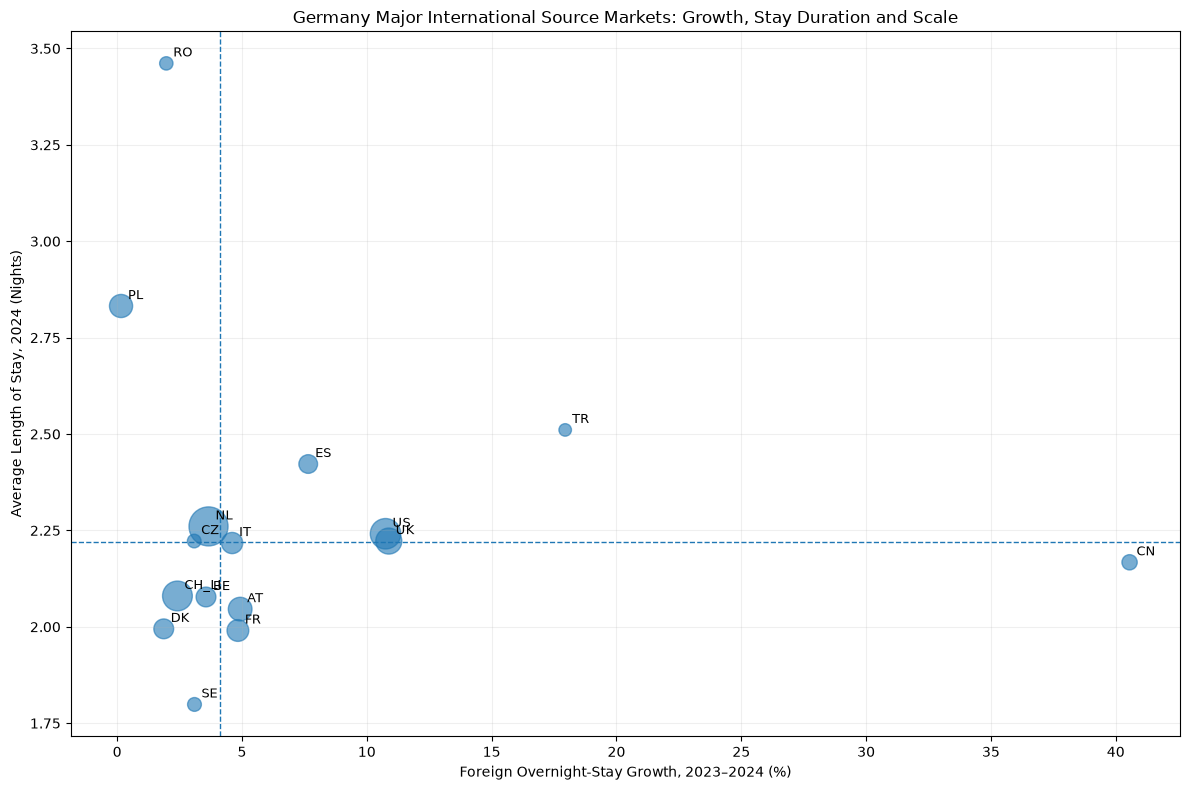

In [38]:
plt.figure(
    figsize=(12, 8)
)

bubble_sizes = (
    major_markets[
        "foreign_nights"
    ]
    / 15_000
)

plt.scatter(
    major_markets[
        "growth_2023_2024_pct"
    ],
    major_markets[
        "avg_length_of_stay"
    ],
    s=bubble_sizes,
    alpha=0.6
)

for _, row in major_markets.iterrows():
    plt.annotate(
        row[
            "source_market_code"
        ],
        (
            row[
                "growth_2023_2024_pct"
            ],
            row[
                "avg_length_of_stay"
            ]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.axvline(
    major_benchmarks[
        "median_growth_pct"
    ],
    linestyle="--",
    linewidth=1
)

plt.axhline(
    major_benchmarks[
        "median_los"
    ],
    linestyle="--",
    linewidth=1
)

plt.xlabel(
    "Foreign Overnight-Stay Growth, 2023–2024 (%)"
)

plt.ylabel(
    "Average Length of Stay, 2024 (Nights)"
)

plt.title(
    "Germany Major International Source Markets: "
    "Growth, Stay Duration and Scale"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()

## Source-Market Analysis Summary

Germany's international tourism demand is supported by a diversified portfolio of source markets, but the analysis identifies materially different strategic profiles across those markets.

### Core growth markets

The United States and United Kingdom provide the strongest combination of current scale, recent growth, and stay duration among the major markets. Together, they generated approximately 12.50 million overnight stays in 2024 and accounted for approximately 14.74% of Germany's total foreign overnight stays.

These markets are important not only because of their size but because both continued to expand strongly between 2023 and 2024.

### Established markets and retention

The Netherlands remains Germany's largest identified international source market. Poland also combines substantial volume with comparatively long stays. Their lower recent growth means that maintaining established demand may be as strategically relevant as pursuing additional growth.

### Stay-extension opportunities

Several high-volume markets generate comparatively short stays. Switzerland–Liechtenstein, Austria, France, and Italy are particularly relevant because their substantial visitor volumes mean that even relatively small changes in stay patterns could correspond mathematically to meaningful changes in overnight stays.

This identifies a strategic area for investigation rather than demonstrating that stay duration can necessarily be increased through a specific intervention.

### Emerging growth opportunities

Spain and Türkiye combine above-median growth with relatively longer stays but remain below the major-market median for scale.

China represents a different emerging opportunity. It recorded the strongest percentage growth between 2023 and 2024 and one of the largest absolute increases in overnight stays, despite remaining below the major-market medians for scale and stay duration.

China should therefore be evaluated as a high-momentum market rather than solely through its composite opportunity score.

### Strategic implication

The analysis suggests that Germany should avoid a single source-market strategy.

Different market profiles support different strategic questions:

- protect and develop established high-value demand
- support markets demonstrating strong growth momentum
- investigate stay-extension opportunities among large short-stay markets
- monitor emerging markets that may become materially important

The prioritization framework is descriptive rather than causal. Market classifications depend partly on the analytical thresholds selected and should therefore support, rather than replace, broader tourism strategy and market-specific research.

### Sensitivity of the Major-Market Threshold

The strategic segmentation uses 1 million overnight stays in 2024 as the analytical threshold for defining a major source market.

A sensitivity check compared thresholds of 750,000, 1 million, and 1.5 million overnight stays.

The benchmark structure remained reasonably stable around the selected threshold. At both 750,000 and 1 million nights, the median growth rate was 4.13% and the median length of stay was 2.22 nights. Raising the threshold to 1.5 million nights changed the median growth rate to 4.72% and the median length of stay to 2.19 nights.

This suggests that the main strategic interpretation is not highly dependent on the exact 1-million-night threshold, although individual market classifications can change as the composition of the comparison group changes.

In [39]:
plt.savefig(
    figures_dir
    / "germany_source_market_growth_los_2024.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

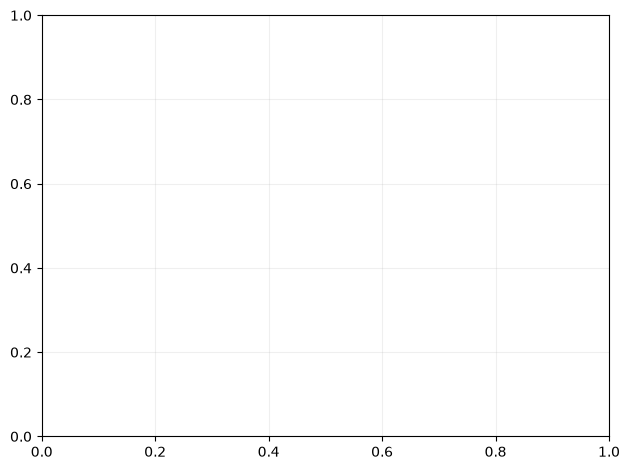

In [40]:
plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.savefig(
    figures_dir
    / "germany_source_market_growth_los_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [41]:
source_market_final = (
    strategic_markets
    .sort_values(
        "foreign_nights",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

source_market_final.to_csv(
    processed_dir
    / "germany_source_market_analysis_2024.csv",
    index=False
)

In [42]:
major_market_final = (
    major_markets[
        [
            "source_market_code",
            "source_market",
            "market_type",
            "foreign_nights",
            "foreign_arrivals",
            "germany_foreign_nights_share_pct",
            "published_market_share_pct",
            "growth_2023_2024_pct",
            "absolute_growth_nights",
            "avg_length_of_stay",
            "high_scale",
            "high_growth",
            "longer_stay",
            "opportunity_score",
            "strategic_role",
            "stay_extension_priority"
        ]
    ]
    .sort_values(
        [
            "opportunity_score",
            "foreign_nights"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)

major_market_final.to_csv(
    processed_dir
    / "germany_major_source_market_strategy_2024.csv",
    index=False
)

In [43]:
strategic_role_summary.to_csv(
    processed_dir
    / "germany_source_market_strategic_roles_2024.csv",
    index=False
)

In [44]:
source_market_coverage.to_csv(
    processed_dir
    / "germany_source_market_coverage_2021_2024.csv",
    index=False
)

In [45]:
threshold_sensitivity.to_csv(
    processed_dir
    / "germany_source_market_threshold_sensitivity.csv",
    index=False
)

In [46]:
output_files = [
    "germany_source_market_analysis_2024.csv",
    "germany_major_source_market_strategy_2024.csv",
    "germany_source_market_strategic_roles_2024.csv",
    "germany_source_market_coverage_2021_2024.csv",
    "germany_source_market_threshold_sensitivity.csv"
]

for file_name in output_files:
    file_path = (
        processed_dir
        / file_name
    )

    print(
        file_name,
        "->",
        file_path.exists()
    )

germany_source_market_analysis_2024.csv -> True
germany_major_source_market_strategy_2024.csv -> True
germany_source_market_strategic_roles_2024.csv -> True
germany_source_market_coverage_2021_2024.csv -> True
germany_source_market_threshold_sensitivity.csv -> True


In [47]:
for file_name in output_files:
    check_df = pd.read_csv(
        processed_dir
        / file_name
    )

    print(
        file_name,
        check_df.shape
    )

germany_source_market_analysis_2024.csv (41, 12)
germany_major_source_market_strategy_2024.csv (16, 16)
germany_source_market_strategic_roles_2024.csv (7, 7)
germany_source_market_coverage_2021_2024.csv (4, 5)
germany_source_market_threshold_sensitivity.csv (3, 5)


# Conclusion

The source-market analysis shows that Germany's international tourism performance cannot be understood through market size alone. Source markets differ substantially in scale, recent growth, and average length of stay, creating different strategic profiles.

The United States and United Kingdom emerge as core growth markets because they combine substantial overnight-stay volume, above-median recent growth, and above-median stay duration among the major markets.

The Netherlands remains Germany's largest identified international source market, while Poland combines substantial scale with comparatively long stays. These established markets are particularly relevant for retention and value preservation.

Austria, France, and Italy combine substantial scale and recent growth with comparatively shorter stays. Switzerland–Liechtenstein also represents a large short-stay market despite slower recent growth. These markets are therefore relevant when investigating Germany's broader stay-duration challenge.

China represents a distinct emerging opportunity. It recorded the strongest percentage growth between 2023 and 2024 and one of the largest absolute increases in overnight stays, despite remaining below the major-market medians for scale and stay duration.

The sensitivity analysis indicates that the major-market benchmark structure remains reasonably stable around the selected 1-million-night threshold.

Overall, the findings support a differentiated source-market strategy rather than a single ranking of markets. Established demand, growth momentum, and stay duration represent separate strategic dimensions and should be evaluated together.

The strategic classifications used in this notebook are descriptive prioritization tools. They do not establish causal relationships or demonstrate that a particular tourism intervention will increase arrivals, overnight stays, or length of stay.